# Regression Analysis

### Import Libraries

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import rfft, rfftfreq
from scipy.optimize import curve_fit
from scipy.special import erf

from helpers import process, osc_initial_params

### Process File

In [213]:
# Metals: bismuth & antimony
metal = "bismuth"

# Power: 0.71, 14.9, 30.1, 45.8, 60.7, 72.3, 90.4, 104.6
power = "0.71"

# Baseline: initial level
baseline = 5

voltage_np, time_np = process(metal, power, baseline) # Processes file


# antimony: 139.18162010600014, bismuth: 139.14225954276674
if metal == "antimony":
    t0 = 139.18162010600014
if metal == "bismuth":
    t0 = 139.14225954276674

time_np = time_np-t0



### Envelope Fitting

**Envelope Model**

$$ \text{envelope} = \frac{1}{2}\left[1+\text{erf}\left(\frac{t-t_{0}}{\tau_{0}}\right)\right]\left[A_{0}e^{-\frac{t-t_{0}}{\tau_{1}}} + A_{1} \right] $$

In [34]:
def env_model(t, t0, tau0, tau1, A0, A1):
    return (1/2) * (1 + erf((t-t0)/tau0)) * (A0 * np.exp(-(t-t0)/tau1) + A1)

**Initial Parameters Guess**

In [214]:
# t0
peak_idx = np.argmin(voltage_np)
t0_guess = time_np[peak_idx]

# tau0

# voltage range
v_range = voltage_np.max() - voltage_np.min()

# excitation amplitude
amplitude = baseline - voltage_np.min()  # positive number

p0 = [t0_guess, 0.3, 5.0, -amplitude, 0.1 * v_range]

bounds = (
    [t0_guess - 0.5, 0.05, 0.1,  -5 * amplitude,  -2 * v_range],
    [t0_guess + 0.5, 3.0, 50, 0, 2 * v_range],
)

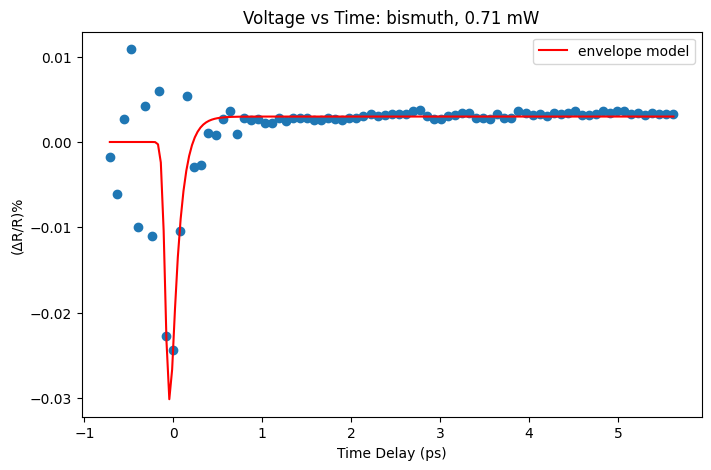

[-0.0687523   0.05        0.1        -0.05482043  0.00298476]


In [215]:
popt, _ = curve_fit(env_model, time_np, voltage_np, p0=p0, bounds=bounds, maxfev=50000)
t0, tau0, tau1, A0, A1 = popt

t_smooth = np.linspace(np.min(time_np), np.max(time_np), 200)


# Create and size figure
fig = plt.figure(figsize=(8,5))

plt.scatter(time_np, voltage_np)
plt.plot(
    t_smooth,
    env_model(t_smooth, t0, tau0, tau1, A0, A1),
    color = "r",
    label = "envelope model"
)

plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
        plt.ylabel(f"(\u0394R/R)%")
else:
        plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"Voltage vs Time: {metal}, {power} mW")
plt.legend()
# fig.savefig(f"bismuth_env.pdf", dpi=300, bbox_inches="tight")

plt.show()

print(popt)

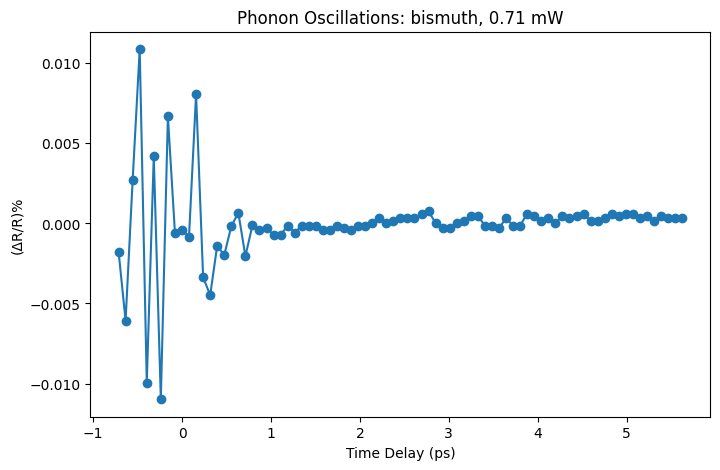

In [216]:
osc = voltage_np-env_model(time_np, t0, tau0, tau1, A0, A1)

# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time_np, osc)
plt.plot(time_np, osc)

plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
        plt.ylabel(f"(\u0394R/R)%")
else:
        plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"Phonon Oscillations: {metal}, {power} mW")

# fig.savefig(f"bismuth_osc.pdf", dpi=300, bbox_inches="tight")

plt.show()

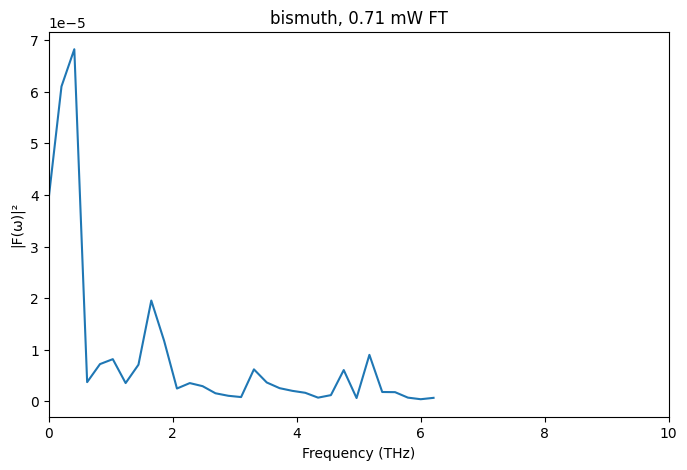

In [217]:
# Average difference between time points
dt = np.mean(np.diff(time_np))

# Produces range of frequencies from oscillation and time data
freqs = rfftfreq(len(osc[20:]), dt)
# Foruier transforms data and makes it all positive
spectrum = np.abs(rfft(osc[20:]))**2


# Plot frequency data
fig = plt.figure(figsize=(8,5))
plt.plot(freqs, spectrum)
plt.xlabel("Frequency (THz)")
plt.ylabel("|F(\u03c9)|\u00B2")
plt.title(f"{metal}, {power} mW FT")
plt.xlim(0, 10)

# fig.savefig(f"bismuth_FT.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [183]:
def peak_in_range(freqs, spectrum, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    idx = np.argmax(spectrum[mask])
    return freqs[mask][idx]

f_1 = peak_in_range(freqs, spectrum, 0, 1)
f_2  = peak_in_range(freqs, spectrum, 4, 6)

print(f_1)
print(f_2)

w01 = 2 * np.pi * f_1
w02 = 2 * np.pi * f_2

print(w01)
print(w02)

0.2069318088006901
4.552499793615182
1.3001909006445913
28.60419981418101


$$ \text{signal} = \frac{\Delta R}{R} - \text{envelope} = \frac{1}{2}\left[1+\text{erf}\left(\frac{t-t_{0}}{\tau_{0}}\right)\right]\left[A_{\text{osc}_{1}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}_{1}}}}cos(\omega_{\text{osc}_{1}}t + \phi_{\text{osc}_{1}}) + A_{\text{osc}_{2}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}_{2}}}}cos(\omega_{\text{osc}_{2}}t + \phi_{\text{osc}_{2}}) \right] $$ 

**Oscillation Model**

In [218]:
def osc_model(t, tau0, A01, tau01, w01, phi01, A02, tau02, w02, phi02):
    dt = t - t0
    onset = (1/2) * (1 + erf(dt / tau0))
    
    exp1 = np.exp(-np.clip(dt, 0, None) / tau01) 
    exp2 = np.exp(-np.clip(dt, 0, None) / tau02)
    # Clip prevents errors from this exponential going to infinity

    osc1 = np.cos(w01*t + phi01)
    osc2 = np.cos(w02*t + phi02)
    
    return onset * (A01 * exp1 * osc1 + A02 * exp2 * osc2)

**Initial Guess, Bounds and Curve Fit**

In [222]:
# Guess and Bounds
p0, bounds = osc_initial_params(time_np[24:], osc[24:], t0, tau0)

# Curve Fit
popt, pcov = curve_fit(osc_model, time_np[24:], osc[24:], p0=p0, bounds=bounds, maxfev=80000)

**Plot Model**

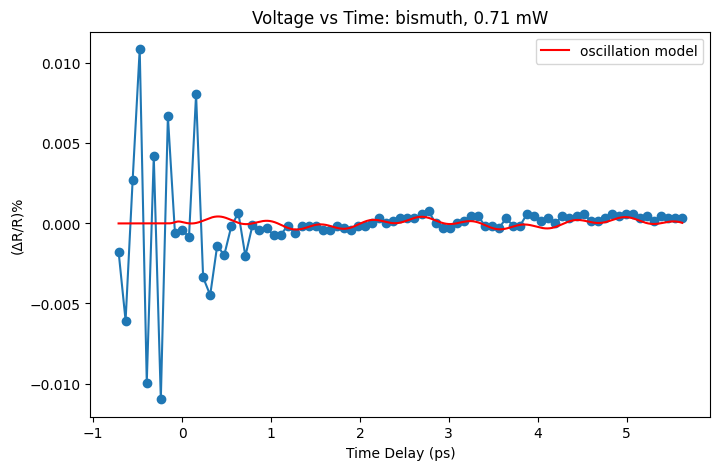

[ 5.00000000e-02  1.93529934e-04  2.84665504e+01  1.09772088e+01
  1.78357319e+00  2.47735065e-04  1.13849696e+02  2.75659415e+00
 -1.00799397e+00]


In [223]:
t_smooth = np.linspace(np.min(time_np), np.max(time_np), 4000)

# Create and size figure
fig = plt.figure(figsize=(8,5))

plt.scatter(time_np, osc)
plt.plot(time_np, osc)
plt.plot(
    t_smooth,
    osc_model(t_smooth, *popt),
    color = "r",
    label = "oscillation model"
)

plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
        plt.ylabel(f"(\u0394R/R)%")
else:
        plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"Voltage vs Time: {metal}, {power} mW")
plt.legend()

# fig.savefig(f"antimony_osc_model.pdf", dpi=300, bbox_inches="tight")

plt.show()

print(popt)

R^2 = 0.3722
RMS resid = 0.040 µV


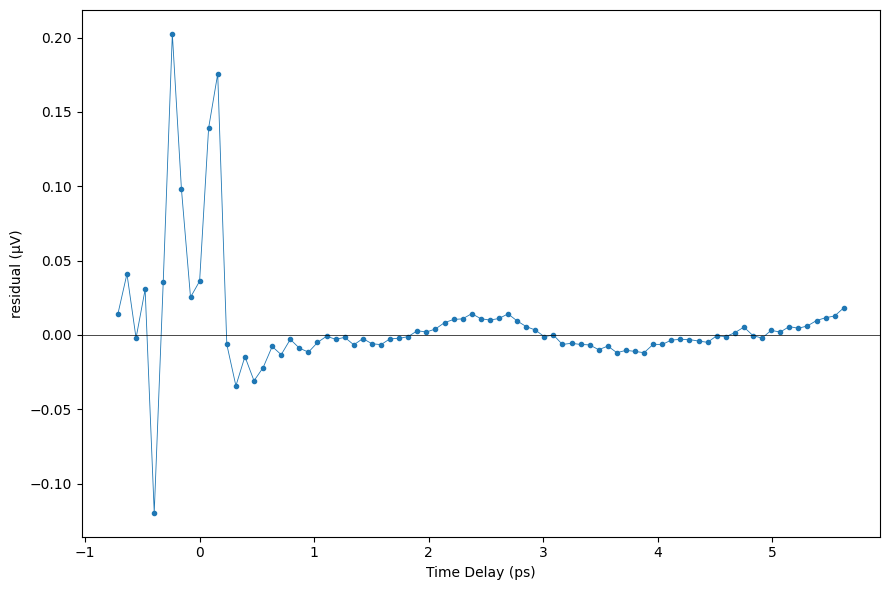

In [152]:
# Goodness of fit
resid = osc - osc_model(time_np, *popt)
R2 = 1 - np.sum(resid**2) / np.sum((osc - osc.mean())**2)
print(f"R^2 = {R2:.4f}")
print(f"RMS resid = {np.sqrt(np.mean(resid**2)):.3f} µV")

# Plot data + fit + residuals
plt.figure(figsize=(9, 6))
plt.plot(time_np, resid, 'o-', ms=3, lw=0.6)
plt.axhline(0, c='k', lw=0.5)
plt.xlabel('Time Delay (ps)')
plt.ylabel('residual (µV)')
plt.tight_layout()
#plt.savefig('fit_classmodel.png', dpi=130)
plt.show()

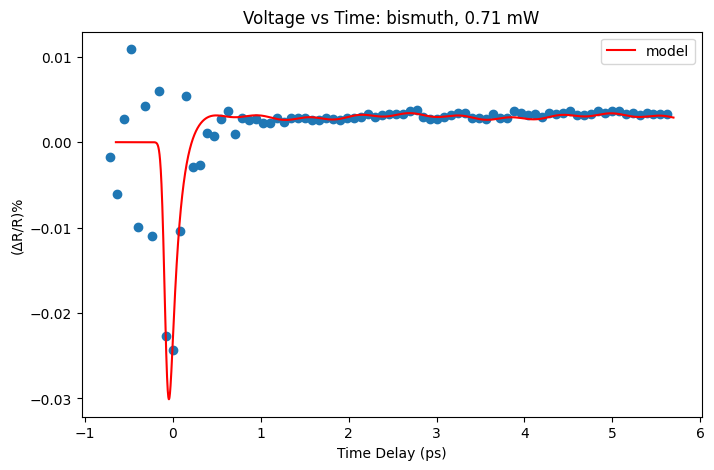

In [224]:
# Create and size figure
fig = plt.figure(figsize=(8,5))
plt.scatter(time_np, voltage_np)
plt.plot(
    t_smooth-t0,
    env_model(t_smooth-t0, t0, tau0, tau1, A0, A1) + osc_model(t_smooth-t0, *popt),
    color = "r",
    label = "model"
)

plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
    plt.ylabel(f"(\u0394R/R)%")
else:
    plt.ylabel(f"Voltage(\u00B5V)")
plt.title(f"Voltage vs Time: {metal}, {power} mW")
plt.legend()

# fig.savefig(f"bismuth_full_model.pdf", dpi=300, bbox_inches="tight")

plt.show()

R^2 = 0.6569
RMS resid = 0.381 µV


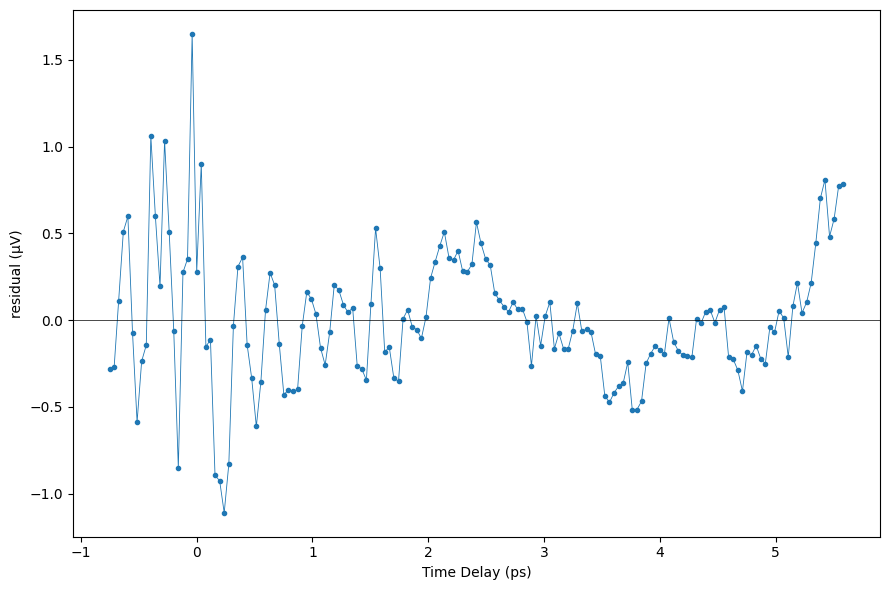

In [52]:
# Goodness of fit
resid = voltage_np - (env_model(time_np, t0, tau0, tau1, A0, A1) + osc_model(time_np, *popt))
R2 = 1 - np.sum(resid**2) / np.sum((osc - osc.mean())**2)
print(f"R^2 = {R2:.4f}")
print(f"RMS resid = {np.sqrt(np.mean(resid**2)):.3f} µV")

# Plot data + fit + residuals
plt.figure(figsize=(9, 6))
plt.plot(time_np, resid, 'o-', ms=3, lw=0.6)
plt.axhline(0, c='k', lw=0.5)
plt.xlabel('Time Delay (ps)')
plt.ylabel('residual (µV)')
plt.tight_layout()
plt.savefig('antimony_residuals.pdf', dpi=130)
plt.show()

In [126]:
curves = []

In [225]:
curves.append(env_model(t_smooth, t0, tau0, tau1, A0, A1) + osc_model(t_smooth-t0, *popt))

In [113]:
powers = [104.6, 90.4, 72.3, 60.7, 45.8, 30.1, 14.9, 0.71]

In [212]:
for c in curves:
    print(len(c))

4000
4000
4000
4000
4000
4000
4000


In [57]:
print(curves)

[array([-0.40907223, -0.38450239, -0.35938644, ...,  5.38706426,
        5.38117944,  5.37525632], shape=(4000,))]


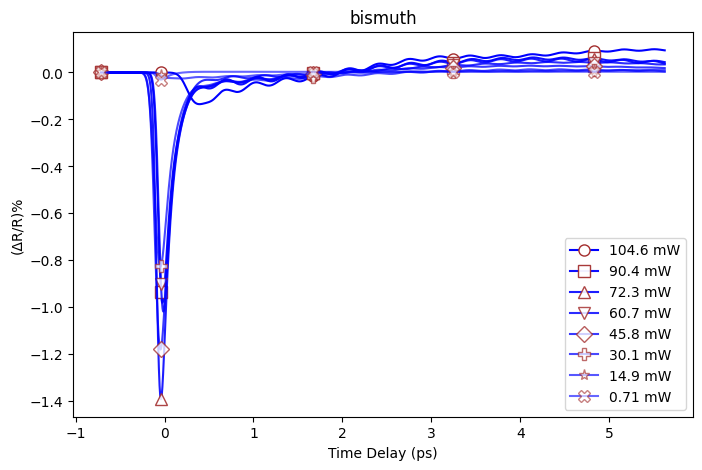

In [227]:
fig = plt.figure(figsize=(8,5))  # wider figure, same data range
n = len(curves)

markers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', '<', '>']

for i, curve in enumerate(curves):
    
    power = powers[i]

    alpha = 1.0 - 0.4 * (i / (n - 1)) if n > 1 else 1.0
    plt.plot(t_smooth, curve,
             color='blue', alpha=alpha,
             marker=markers[i % len(markers)],
             markevery= [0, 425, 1500, 2500, 3500],
             markerfacecolor='white',
             markeredgecolor='#A32D2D',
             markersize=8,
             label=f"{power} mW")
plt.title(f"{metal}")
plt.xlabel("Time Delay (ps)")
if metal == "bismuth":
    plt.ylabel("(\u0394R/R)%")
else:
    plt.ylabel("Voltage (\u00B5V)")
plt.legend()
fig.savefig(f"{metal}_models.pdf", dpi=300, bbox_inches="tight")

plt.show()

